In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *

In [2]:
chunk_acc = pd.read_csv(f'accounts.csv', chunksize=10000)
chunk_trns = pd.read_csv(f'transactions.csv', chunksize=10000)

accounts = pd.concat(chunk_acc)
transactions = pd.concat(chunk_trns)

# accounts = pd.read_csv('accounts.csv')
# transactions = pd.read_csv('transactions.csv')

In [3]:
balances = {
    acc_id: [{"date": 0, "balance": round(float(init_bal), 2)}]
    for acc_id, init_bal in zip(accounts["ACCOUNT_ID"], accounts["INIT_BALANCE"])
}

In [4]:
import pandas as pd
from scipy.sparse import lil_matrix
from scipy import sparse


transactions.sort_values(by="TX_ID", inplace=True)

max_account_id = max(transactions["SENDER_ACCOUNT_ID"].max(),
                     transactions["RECEIVER_ACCOUNT_ID"].max()) + 1

print(max_account_id)

matrix = lil_matrix((max_account_id, max_account_id), dtype=int)


for row in transactions.itertuples(index=False):
    orig_acct = row.SENDER_ACCOUNT_ID
    bene_acct = row.RECEIVER_ACCOUNT_ID
    amount = float(row.TX_AMOUNT)
    tx_type = row.TX_TYPE
    date = row.TIMESTAMP

    # Update sparse matrix
    matrix[orig_acct, bene_acct] += amount

    # Process sender
    if tx_type in ['TRANSFER', 'WITHDRAWAL'] and orig_acct in balances:
        last_balance = balances[orig_acct][-1]["balance"]
        new_balance = last_balance - amount
        balances[orig_acct].append({
            "date": date,
            "balance": round(new_balance, 2)
        })

    # Process receiver
    if tx_type in ['TRANSFER', 'DEPOSIT'] and bene_acct in balances:
        last_balance = balances[bene_acct][-1]["balance"]
        new_balance = last_balance + amount
        balances[bene_acct].append({
            "date": date,
            "balance": round(new_balance, 2)
        })


100


In [5]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}, {'date': 2, 'balance': 253.63}, {'date': 3, 'balance': 322.82}, {'date': 7, 'balance': 374.37}, {'date': 13, 'balance': 443.56}, {'date': 16, 'balance': 351.34}, {'date': 16, 'balance': 259.12}, {'date': 18, 'balance': 310.67}, {'date': 23, 'balance': 379.86}, {'date': 26, 'balance': 287.64}, {'date': 26, 'balance': 195.42}, {'date': 27, 'balance': 103.2}, {'date': 27, 'balance': 10.98}, {'date': 27, 'balance': 62.53}, {'date': 29, 'balance': -29.69}, {'date': 29, 'balance': -121.91}, {'date': 30, 'balance': -52.72}, {'date': 31, 'balance': 16.47}, {'date': 37, 'balance': -75.75}, {'date': 37, 'balance': -167.97}, {'date': 38, 'balance': -116.42}, {'date': 49, 'balance': -47.23}, {'date': 49, 'balance': -139.45}, {'date': 49, 'balance': -231.67}, {'date': 51, 'balance': -162.48}, {'date': 53, 'balance': -93.29}, {'date': 57, 'balance': -185.51}, {'date': 57, 'balance': -277.73}, {'date': 58, 'balance': -226.18}, {'date': 68, 'balance': -318.4}, {'date

In [6]:
import pandas as pd

# Step 1: Flatten the balances dict to a DataFrame
records = []

for user_id, history in balances.items():
    for entry in history:
        records.append({
            "ACCOUNT_ID": user_id,
            "TIMESTAMP": entry["date"],
            "BALANCE": entry["balance"]
        })

df_balances = pd.DataFrame(records)

# Step 2: Sort by timestamp and user, then remove duplicates keeping the latest
df_balances.sort_values(by=["ACCOUNT_ID", "TIMESTAMP"], inplace=True)
df_balances.drop_duplicates(subset=["ACCOUNT_ID", "TIMESTAMP"], keep="last", inplace=True)

# Step 3: Create a full grid of all timestamps and all users
all_dates = sorted(transactions["TIMESTAMP"].unique())
all_users = df_balances["ACCOUNT_ID"].unique()
grid = pd.MultiIndex.from_product([all_users, all_dates], names=["ACCOUNT_ID", "TIMESTAMP"])

# Step 4: Reindex the balance DataFrame to the full grid
df_balances = df_balances.set_index(["ACCOUNT_ID", "TIMESTAMP"])
df_balances = df_balances.reindex(grid)

# Step 5: Forward fill missing balances (per user)
df_balances["BALANCE"] = df_balances["BALANCE"].groupby(level=0).ffill()

# Step 6: Reset index and pivot to get final table: one row per date, one column per user
df = df_balances.reset_index().pivot(index="TIMESTAMP", columns="ACCOUNT_ID", values="BALANCE")
df.index.name = "date"
df.columns = df.columns.astype(str)  # match your original str(user) keys

In [7]:
df

ACCOUNT_ID,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


In [8]:
Y = df.T.to_numpy()

In [9]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [10]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 5.712418789647363
Min: -5.798787369198431
Mean std per row (should be 1): 1.0


In [11]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2]

In [12]:
Theta_dict = {}

In [13]:
ROWS = Y_new.shape[0]
ROWS

100

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.17e-03 nnz(S)/p=3.68e+01
* iter=1 time=1.07e-02 obj=1.72e+02 |delta(obj)|/obj=4.20e-01 nnz(X,L,W)/p=[3.68e+01 2.19e+01 3.13e+01] lns_iter=3 
* iter=2 time=3.83e-03 obj=1.69e+02 |delta(obj)|/obj=2.30e-02 nnz(X,L,W)/p=[3.68e+01 2.19e+01 5.35e+01] lns_iter=1 
* iter=3 time=7.80e-03 obj=1.66e+02 |delta(obj)|/ob

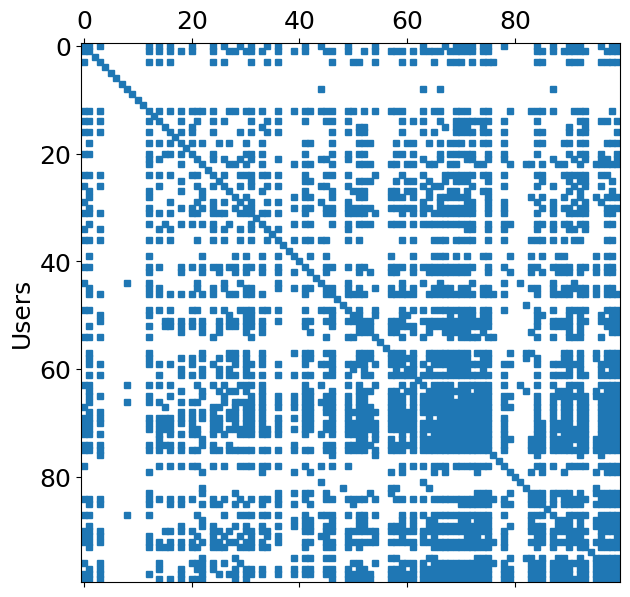

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.47e-04 nnz(S)/p=7.40e+01
* iter=1 time=4.86e-03 obj=1.26e+02 |delta(obj)|/obj=2.08e-01 nnz(X,L,W)/p=[7.40e+01 4.21e+01 7.58e+01] lns_iter=6 
* iter=2 time=1.08e-02 obj=1.25e+02 |delta(obj)|/obj=9.42e-03 nnz(X,L,W)/p=[7.71e+01 4.09e+01 9.75e+01] lns_iter=1 
* iter=3 time=2.55e-02 obj=1.24e+02 |delta(obj)|/ob

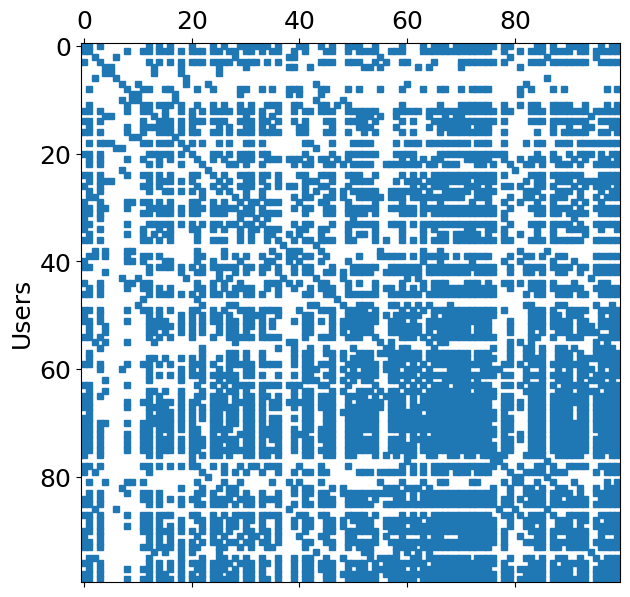

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.31e-04 nnz(S)/p=8.93e+01
* iter=1 time=2.55e-03 obj=7.01e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[8.93e+01 4.92e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.45e-03 obj=6.63e+01 |delta(obj)|/obj=5.72e-02 nnz(X,L,W)/p=[8.93e+01 4.92e+01 9.41e+01] lns_iter=10 
* iter=3 time=2.61e-02 obj=6.01e+01 |delta(obj)|/o

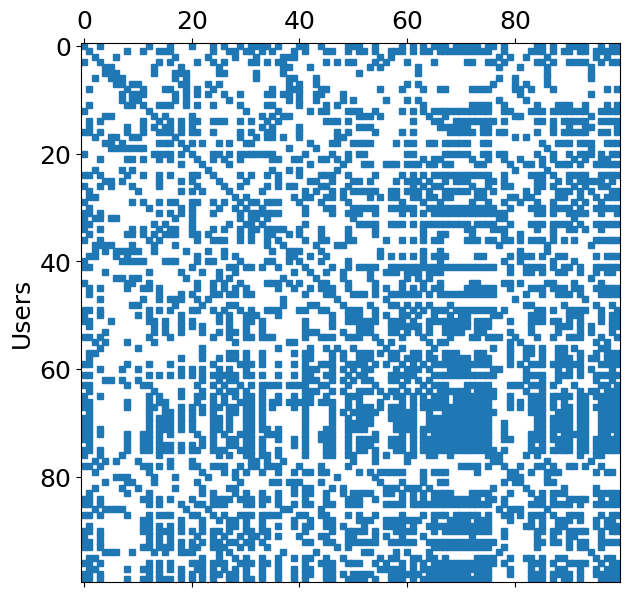

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.93e-04 nnz(S)/p=9.44e+01
* iter=1 time=2.51e-03 obj=7.61e+01 |delta(obj)|/obj=3.14e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.42e-03 obj=5.98e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 9.15e+01] lns_iter=9 
* iter=3 time=2.81e-02 obj=4.32e+01 |delta(obj)|/ob

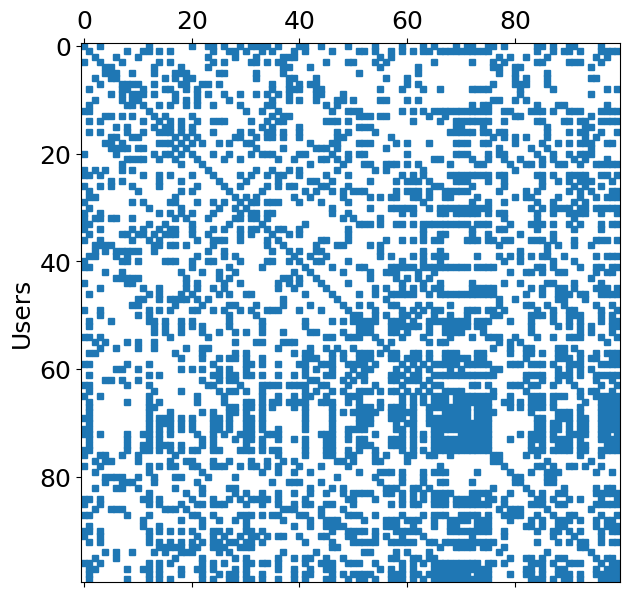

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.45e-04 nnz(S)/p=9.48e+01
* iter=1 time=2.49e-03 obj=7.42e+01 |delta(obj)|/obj=3.48e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.88e-03 obj=5.74e+01 |delta(obj)|/obj=2.92e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 9.17e+01] lns_iter=9 
* iter=3 time=2.82e-02 obj=4.14e+01 |delta(obj)|/ob

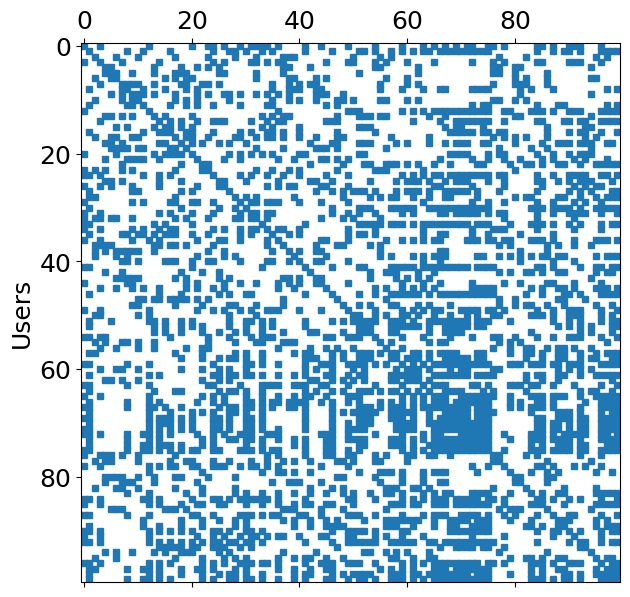

In [14]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    Theta, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    print(f"time required: {computation_time} seconds")

    Theta = sparse.csr_matrix(Theta) # store Theta as sparse
    Theta_dict[rho] = Theta

    nonz, nonz_r = nnz_sparse(Theta_dict[rho], ROWS)

    print("Checking if symmetric")
    if check_symmetric_sparse(Theta_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(Theta_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(Theta_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(Theta_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.96e+01 time=3.77e-04
* iter=1 time=1.17e-03 obj=4.98e+03 |delta(obj)|/obj=9.80e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 1.10e+00] lns_iter=3 
* iter=2 time=2.40e-03 obj=4.38e+03 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 5.07e+01] lns_iter=4 
* iter=3 time=6.74e-03 obj=3.88e+03 |de

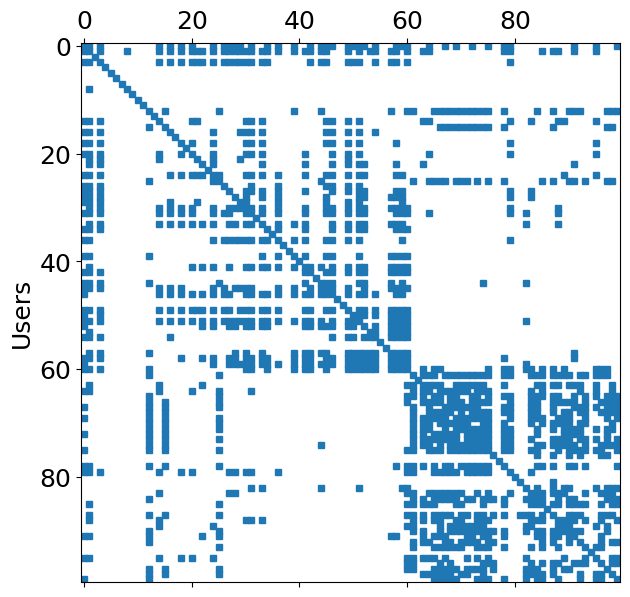

✅ Matrix is symmetric per rho 0.9

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=6.14e+01 time=4.32e-04
* iter=1 time=1.96e-03 obj=6.34e+03 |delta(obj)|/obj=9.84e-01 nnz(X,L,W)/p=[6.14e+01 3.93e+01 1.00e+00] lns_iter=6 
* iter=2 time=3.37e-03 obj=6.32e+03 |delta(obj)|/obj=4.20e-03 nnz(X,L,W)/p=[6.14e+01 3.93e+01 7.38e+01] lns_iter=9 
* ite

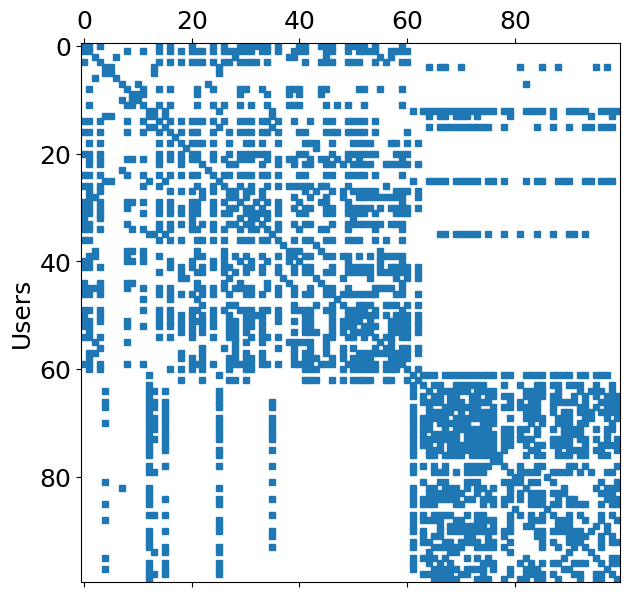

✅ Matrix is symmetric per rho 0.5

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=7.47e+01 time=4.89e-04
* iter=1 time=2.49e-03 obj=6.40e+03 |delta(obj)|/obj=9.84e-01 nnz(X,L,W)/p=[7.47e+01 4.71e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.18e-03 obj=6.37e+03 |delta(obj)|/obj=5.29e-03 nnz(X,L,W)/p=[7.47e+01 4.71e+01 8.63e+01] lns_iter=9 
* ite

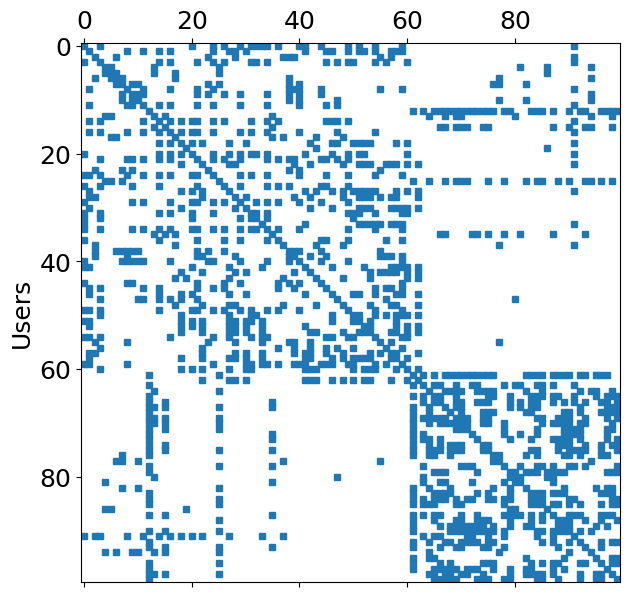

✅ Matrix is symmetric per rho 0.2

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=7.92e+01 time=4.04e-04
* iter=1 time=2.14e-03 obj=6.38e+03 |delta(obj)|/obj=9.84e-01 nnz(X,L,W)/p=[7.92e+01 5.00e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.08e-03 obj=6.36e+03 |delta(obj)|/obj=2.78e-03 nnz(X,L,W)/p=[7.92e+01 5.00e+01 9.31e+01] lns_iter=10 
* it

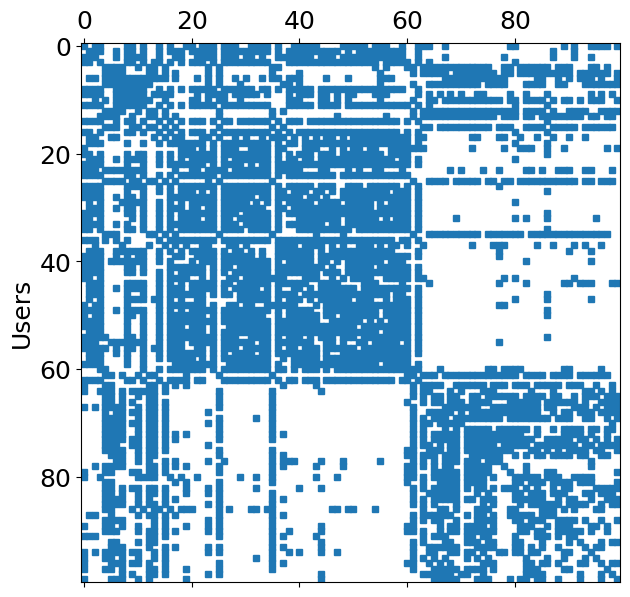

✅ Matrix is symmetric per rho 0.1

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=7.95e+01 time=5.19e-04
* iter=1 time=2.17e-03 obj=6.38e+03 |delta(obj)|/obj=9.84e-01 nnz(X,L,W)/p=[7.95e+01 5.00e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.22e-03 obj=6.36e+03 |delta(obj)|/obj=2.77e-03 nnz(X,L,W)/p=[7.95e+01 5.00e+01 9.37e+01] lns_iter=10 
* it

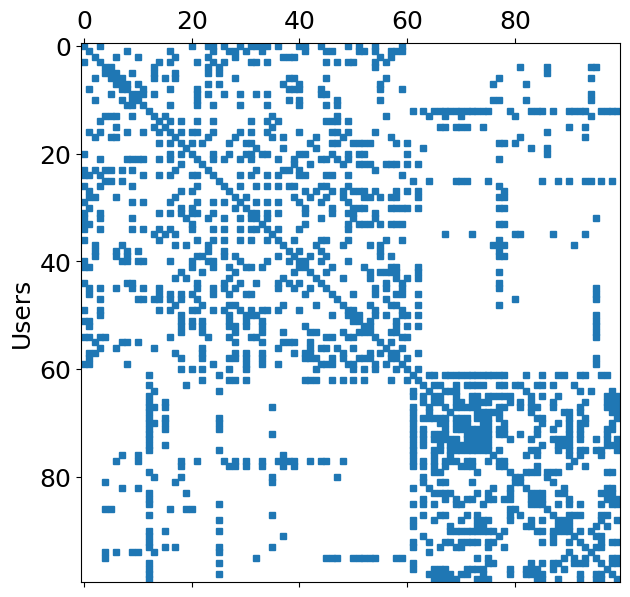

✅ Matrix is symmetric per rho 0.09


In [15]:
W_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    W, end_time = squic_fit_matrix_sparse(Y_new, l=rho, matrix=matrix)
    W_dict[rho] = sparse.csr_matrix(W)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_sparse(W_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(W_dict[rho])

    if check_symmetric_sparse(W_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


In [37]:
X = W_dict[0.5]
X.todense()
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1990 stored elements and shape (100, 100)>
  Coords	Values
  (0, 1)	0.007848326366324616
  (0, 3)	0.0345479654918677
  (0, 14)	0.008658218832974057
  (0, 16)	0.014297337981241416
  (0, 20)	0.020735968561329497
  (0, 24)	0.02399925152756369
  (0, 26)	0.04473814326224648
  (0, 29)	0.03867739565540417
  (0, 30)	0.0020483615413827427
  (0, 31)	0.03297931502888417
  (0, 32)	0.018494937345459435
  (0, 33)	0.018719777852041274
  (0, 34)	0.04823905293631149
  (0, 36)	0.04072796825043935
  (0, 40)	0.02730572458193542
  (0, 41)	0.02578748657909719
  (0, 44)	4.6861667011735596e-05
  (0, 45)	0.0066144004013025046
  (0, 46)	0.004508193115011397
  (0, 49)	0.029133468592649744
  (0, 50)	0.01520380873527842
  (0, 51)	0.01807488582257214
  (0, 52)	0.0009079134807614096
  (0, 54)	0.032385683862086435
  (0, 59)	0.028340143610327412
  :	:
  (98, 84)	0.020241955897462548
  (98, 85)	0.033194879214736905
  (98, 87)	2.570596628333415e-05
  (98, 91)

In [16]:
from tabulate import tabulate

In [17]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [18]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤═══════╤═══════╤═══════╤═══════╤════════╕
│  SQUIC NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │
╞══════════════╪═══════╪═══════╪═══════╪═══════╪════════╡
│     NNZ      │ 2774  │ 4372  │ 3574  │ 3088  │  3120  │
├──────────────┼───────┼───────┼───────┼───────┼────────┤
│   NNZ/Row    │ 27.74 │ 43.72 │ 35.74 │ 30.88 │  31.2  │
├──────────────┼───────┼───────┼───────┼───────┼────────┤
│   Time (s)   │ 0.06  │ 0.31  │ 0.24  │ 1.12  │  1.03  │
├──────────────┼───────┼───────┼───────┼───────┼────────┤
│  Symmetric   │  Yes  │  Yes  │  Yes  │  Yes  │  Yes   │
╘══════════════╧═══════╧═══════╧═══════╧═══════╧════════╛
╒══════════════════╤═══════╤═══════╤═══════╤═══════╤════════╕
│  SQUIC FIT NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │
╞══════════════════╪═══════╪═══════╪═══════╪═══════╪════════╡
│       NNZ        │ 1590  │ 2090  │ 1502  │ 4114  │  1542  │
├──────────────────┼───────┼───────┼───────┼───────┼────────┤
│     NNZ/Row      │ 15.9  │ 20.9  │ 15.02 │ 41.14 │

In [19]:
def labels_to_partition(labels):
    """Convert label array [0,0,1,1,2,2] -> list of sets [{0,1},{2,3},{4,5}]"""
    clusters = {}
    for idx, label in enumerate(labels):
        if label not in clusters:
            clusters[label] = set()
        clusters[label].add(idx)

    # Remove noise points if using DBSCAN (-1 labels)
    if -1 in clusters:
        noise_nodes = clusters.pop(-1)
        for node in noise_nodes:
            clusters[f'noise_{node}'] = {node}  # unique labels for noise

    return list(clusters.values())

In [44]:
import networkx as nx
from networkx.algorithms import community
from sklearn.cluster import DBSCAN, SpectralClustering
from sklearn.manifold import SpectralEmbedding
from tqdm.auto import tqdm  # Correct import for progress bars

def clustering(W_matrices):
    dict_cluster = {
        "louvain" : {},
        "spectral" : {},
        "dbscan" : {}
    }

    for rho, W in W_matrices.items():
        # Ensure all off-diagonal entries are positive and diagonal is zero
        W.data = np.abs(W.data)
        W.setdiag(0)
        W.eliminate_zeros()  # Remove explicit zeros

        # Create a graph from matrix W
        G = nx.from_scipy_sparse_array(W)

        embedding = SpectralEmbedding(n_components=10, affinity='precomputed')
        X = embedding.fit_transform(W)      

        # Louvain
        partition = community.louvain_communities(G)
        print(f"n cluster louvain : {len(partition)}")
        dict_cluster['louvain'][rho] = partition

        n_cluster_louvain =  len(partition)


        # DBSCAN with multiple params
        best_score = float('inf')
        best_params = None

        eps_range = np.linspace(0.1, 2.0, 20)
        min_samples_range = range(3, 10)

        for eps in tqdm(eps_range):
            for min_samples in min_samples_range:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(X)
                
                # Ignore if all points are noise (-1) or single cluster
                if len(set(labels)) <= 1 or (set(labels) == {-1}):
                    continue

                partition = labels_to_partition(labels)

                diff = abs(len(partition) - n_cluster_louvain)
                if diff < best_score:
                    best_score = diff
                    best_params = (eps, min_samples)

        if best_params is not None:
            print(f"Best params: eps={best_params[0]}, min_samples={best_params[1]}")
            print(f"Best difference in number of clusters: {best_score:.4f}")
            dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
        else:
            print("No suitable DBSCAN parameters found!")
            dbscan = DBSCAN()

        labels_dbscan = dbscan.fit_predict(X)
        print(f"n cluster dbscan = {len(labels_dbscan)}")

        # Convert labels to list of sets
        partition_dbscan = labels_to_partition(labels_dbscan)
        dict_cluster['dbscan'][rho] = partition_dbscan


        # Use n_cluster = len(partitionin louvain)
        clustering = SpectralClustering(n_clusters=n_cluster_louvain, affinity='precomputed', assign_labels='cluster_qr')
        labels_spectral = clustering.fit_predict(X)

        # Convert labels to list of sets
        partition_spectral = labels_to_partition(labels_spectral)
        print(f"n cluster spectral = {len(labels_spectral)}\n")

        dict_cluster['spectral'][rho] = partition_spectral
    
    return dict_cluster

In [45]:
dict_cluster = clustering(W_dict)

# Connected components: 28
Largest component size: 73
n cluster louvain : 29


/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: eps=0.7, min_samples=7
Best difference in number of clusters: 1.0000
n cluster dbscan = 100
n cluster spectral = 100

# Connected components: 2
Largest component size: 99
n cluster louvain : 6


/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


...

Best params: eps=0.4, min_samples=3
Best difference in number of clusters: 1.0000
n cluster dbscan = 100
n cluster spectral = 100

# Connected components: 1
Largest component size: 100
n cluster louvain : 5


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: eps=0.5, min_samples=8
Best difference in number of clusters: 0.0000
n cluster dbscan = 100
n cluster spectral = 100

# Connected components: 1
Largest component size: 100
n cluster louvain : 5


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: eps=0.2, min_samples=3
Best difference in number of clusters: 2.0000
n cluster dbscan = 100
n cluster spectral = 100

